In [ ]:
from _setup import setup_project_root
PROJECT_ROOT = setup_project_root()
PROJECT_ROOT


WindowsPath('C:/Users/huyy/AirPollutionPrediction-CNN-BiLSTM')

In [32]:
import importlib
import evaluation.metrics as metrics

importlib.reload(metrics)

<module 'evaluation.metrics' from 'C:\\Users\\huyy\\AirPollutionPrediction-CNN-BiLSTM\\evaluation\\metrics.py'>

In [42]:
import importlib
import models.lgbm as lgbm

importlib.reload(lgbm)

<module 'models.lgbm' from 'C:\\Users\\huyy\\AirPollutionPrediction-CNN-BiLSTM\\models\\lgbm.py'>

In [43]:
import pandas as pd
from models.lgbm import LGBMBaseConfig, build_xy, fit_model, predict
from evaluation.metrics import compute_metrics, compute_metrics_real_scale


In [ ]:
train_path = PROJECT_ROOT / "data" / "global_split" / "train.csv"
val_path   = PROJECT_ROOT / "data" / "global_split" / "val.csv"
test_path  = PROJECT_ROOT / "data" / "global_split" / "test.csv"

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

In [45]:
cfg = LGBMBaseConfig(
    time_col="date",
    target_col="PM2.5",
    lags=0,
    horizon=24,
    add_hour_feature=False,
    lgbm_params=dict(
        objective="regression",
        n_estimators=800,
        learning_rate=0.05,
        max_depth=8,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
    )
)


In [7]:
extra_feature_cols = [
    "TSP", "O3", "CO", "NO2", "SO2",
    "Temperature", "Humidity",
    "hour", "day_of_week", "hour_sin", "hour_cos",
    "PM2.5_lag1", "PM2.5_roll3",
]

In [46]:
X_train, y_train = build_xy( train_df, cfg, extra_feature_cols=extra_feature_cols)
X_val, y_val = build_xy( val_df, cfg, extra_feature_cols=extra_feature_cols)
X_test, y_test = build_xy( test_df, cfg, extra_feature_cols=extra_feature_cols)

In [47]:
model = fit_model(X_train, y_train, cfg)
pred_test = predict(model, X_test)

In [52]:
metrics = compute_metrics(y_test, pred_test)
metrics

{'Correlation': 0.4286390698013174,
 'RMSE': 0.15774055704271225,
 'MAPE': 9264.131573440201,
 'MAE': 0.11668731787856731}

In [18]:
import joblib
pm25_scaler = joblib.load(PROJECT_ROOT / "artifacts" / "pm25_scaler.pkl")

In [ ]:
metrics_lgbm = compute_metrics_real_scale(
    y_test, pred_test,
    scaler=pm25_scaler,
    mape_threshold=1.0  
)
metrics_lgbm

{'Correlation': 0.42863906980131733,
 'RMSE': 63.67802256638608,
 'MAPE': 0.4753065168410439,
 'MAE': 47.10530887164613}

## Plot

In [54]:
%load_ext autoreload
%autoreload 2

from evaluation.plots import (
    plot_actual_vs_pred,
    plot_scatter_actual_pred,
    plot_residuals_vs_pred,
    plot_error_distribution,
    plot_actual_vs_pred_by_station,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


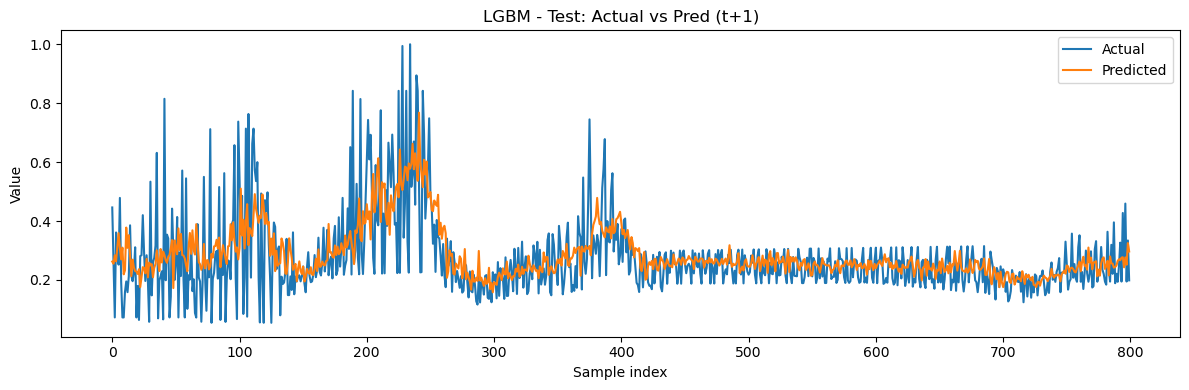

In [55]:
plot_actual_vs_pred(
    y_test, pred_test,
    title="LGBM - Test: Actual vs Pred (t+1)",
    horizon=0,
    n_points=800
)

Đường Predicted (cam) bám theo xu hướng chung của đường Actual (xanh)
→ mô hình học được mức nền và xu thế tổng quát của PM2.5.

Biên độ dự đoán nhỏ hơn biên độ thực tế
→ khi PM2.5 tăng/giảm mạnh, dự đoán tăng/giảm nhẹ và chậm hơn.

Các đỉnh PM2.5 cao bị dự đoán thấp hơn thực tế (underestimation)
→ mô hình không bắt được các spike ô nhiễm ngắn hạn.

Ở các đoạn ổn định (PM2.5 thấp và ít biến động)
→ dự đoán khá sát với giá trị thực, sai số nhỏ hơn.

Có hiện tượng trễ pha nhẹ (phase lag)
→ dự đoán thường tăng hoặc giảm sau thực tế 1–2 bước khi có biến động nhanh.

Đường dự đoán mượt hơn rõ rệt so với đường thực
→ thể hiện hiệu ứng làm mượt (smoothing effect) đặc trưng của LGBM với feature thời gian ngắn.

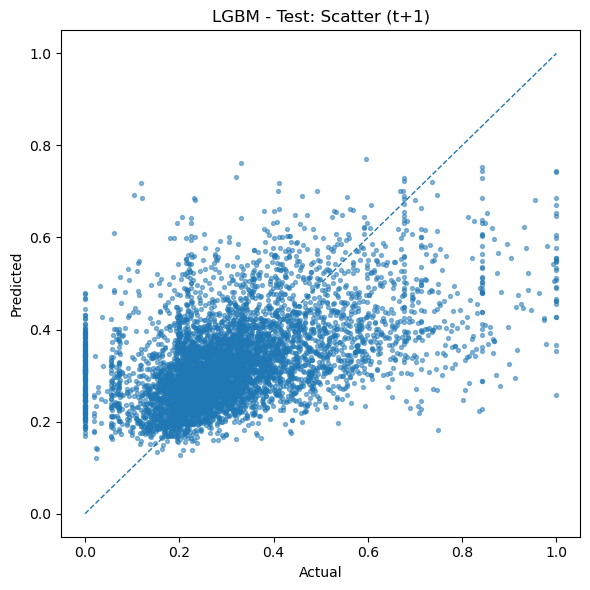

In [56]:
plot_scatter_actual_pred(
    y_test, pred_test,
    title="LGBM - Test: Scatter (t+1)",
    horizon=0,
    sample=6000
)

Các điểm phân bố theo xu hướng tăng, cho thấy:

Khi PM2.5 thực tế tăng thì giá trị dự đoán cũng tăng
→ phù hợp với Correlation ~ 0.43.

Phần lớn điểm nằm dưới đường chéo y = x ở vùng PM2.5 cao
→ mô hình dự đoán thấp hơn thực tế khi nồng độ PM2.5 lớn
→ hiện tượng underestimation ở vùng ô nhiễm cao.

Vùng PM2.5 thấp (Actual ≈ 0–0.2):

các điểm tập trung dày

Predicted dao động hẹp quanh ~0.2–0.3
→ mô hình ổn định và ít sai số hơn ở mức nền thấp.

Độ phân tán của điểm tăng dần khi PM2.5 tăng
→ sai số lớn hơn ở nồng độ cao
→ biểu hiện heteroscedasticity (phương sai sai số không đồng đều).

Không có cụm điểm bám sát hoàn toàn đường y = x
→ mô hình chưa đạt độ chính xác cao, đặc biệt với các giá trị cực trị.

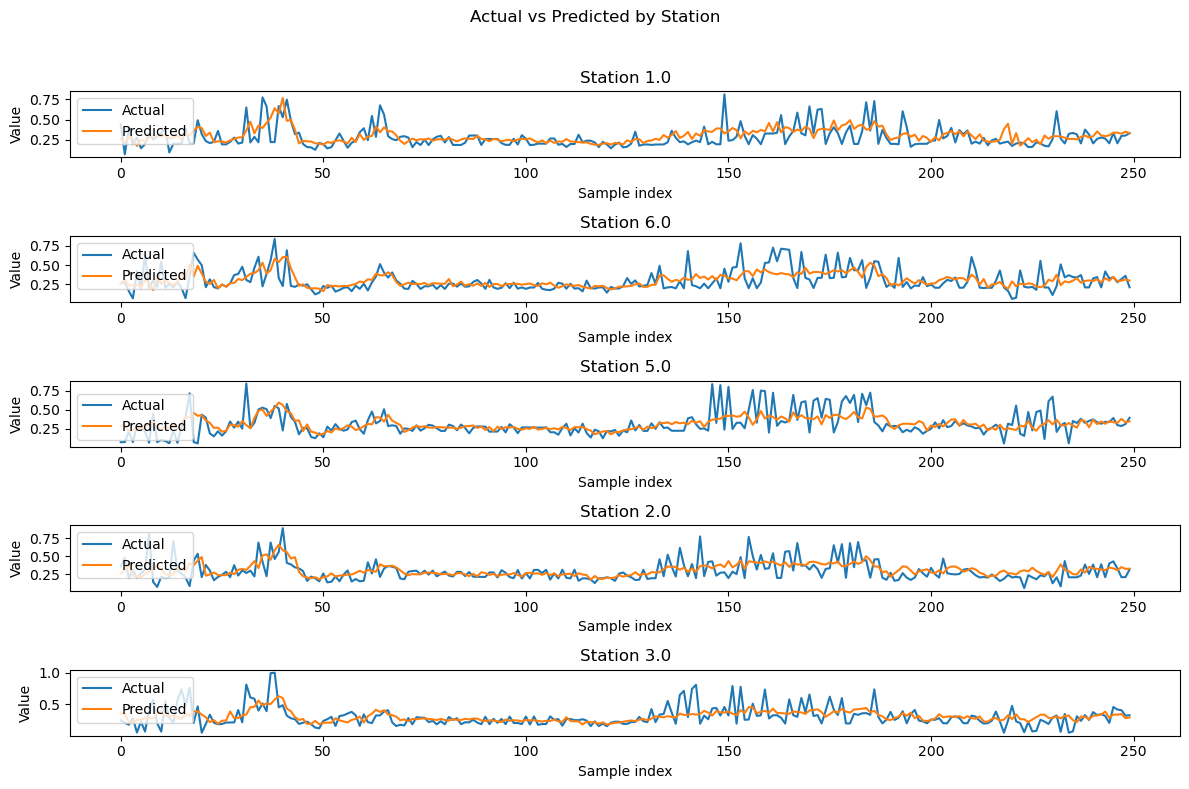

In [60]:
station_ids_aligned = test_df.loc[X_test.index, "Station_No"].to_numpy()
plot_actual_vs_pred_by_station(
    station_ids=station_ids_aligned,
    y_true=y_test,
    y_pred=pred_test,
    horizon=0,
    n_points_per_station=250,
    max_stations=5
)

Ở mọi station, đường Predicted (cam):

mượt hơn

bám xu hướng trung bình

Đường Actual (xanh):

dao động mạnh

nhiều spike ngắn hạn

Cho thấy mô hình học tốt mức nền theo từng station, nhưng không học được các biến động cục bộ mạnh.